In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np

import hmmlearn.hmm as hmm

import lissa as li





In [11]:
PCAData = pd.read_csv("../data/PCA/PCAtotal.csv",delimiter=",").fillna(0)
PCAData.rename(columns={"Unnamed: 0":"time"},inplace=True)

pumpList = PCAData["Well Run"].unique()

complexVib = PCAData["ESP Vibration X"]+1j*PCAData["ESP Vibration Y"]

PCAData["VibMod"] = np.absolute(complexVib)

/tmp/ipykernel_23325/2553270337.py:1: DtypeWarning: Columns (14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  PCAData = pd.read_csv("../data/PCA/PCAtotal.csv",delimiter=",").fillna(0)


In [12]:
n = [3, 2]

nr = n[0]
nv = n[1]

mainSeed = 971215
np.random.seed(mainSeed)

seeds = np.random.randint(low=19971215,high=20210505,size=30)

medianListR = np.array([]).astype(int)
medianListV = np.array([]).astype(int)
for seed in seeds:
    X_train, trainLength, X_test, testLength, modelData, totalLength = li.Splitter(pumpList=pumpList,proportion=0.75,entireData=PCAData)

    radiusData = PCAData["Radius"].loc[PCAData["Well_down"]==0]
    vibData= PCAData["VibMod"].loc[(PCAData["VibMod"]!=0) & (PCAData["Well_down"]==0)].apply(np.log1p)


    modelGMMradius = li.GaussianMixtureFit(radiusData,nr,seed=mainSeed)
    modelGMMvibs = li.GaussianMixtureFit(vibData,nv,seed=mainSeed)

    modelRadius = hmm.GaussianHMM(
        n_components=nr,
        random_state=mainSeed,
        covariance_type="full",
        init_params="st"
        )

    modelVib = hmm.GaussianHMM(
        n_components=nv,
        random_state=mainSeed,
        covariance_type="full",
        init_params="st",
        )

    modelRadius.means_ = modelGMMradius.means_
    modelRadius.covars__ = modelGMMradius.covariances_

    modelVib.means_ = modelGMMvibs.means_
    modelVib.covars_ = modelGMMvibs.covariances_

    modelRadius = li.HMMTrainer(X_train["Radius"],trainLength,modelRadius)
    modelVib = li.HMMTrainer(X_train["VibMod"],trainLength,modelVib)


    li.PostProcessing(modelRadius, PCAData, modelData,"Radius", "State Radius", totalLength)
    li.PostProcessing(modelVib, PCAData, modelData,"VibMod", "State Mod", totalLength)

    PCAData["State Radius"] = PCAData["State Radius"].map(li.StateConversion(modelRadius.get_stationary_distribution(),nr))
    PCAData["State Mod"] = PCAData["State Mod"].map(li.StateConversion(modelVib.get_stationary_distribution(),nv))

    PCAData.loc[(PCAData["VibMod"]==0) & (PCAData["Well_down"]==0),"State Mod"] = 3


    medianListR_G = np.array([])
    medianListV_G = np.array([])

    for pump in pumpList:
        pumpData = PCAData.loc[(PCAData["Well Run"]==pump) & (PCAData["Well_down"]==0) ]#.copy()
        last = pumpData.shape[0]
        pumpMedianR = pumpData.loc[pumpData.index[last-24:last-1],"State Radius"].median()
        pumpMedianV = pumpData.loc[pumpData.index[last-24:last-1],"State Mod"].median()
        medianListR_G = np.append(medianListR_G,pumpMedianR)
        medianListV_G = np.append(medianListV_G,pumpMedianV)

    medianListR = np.concat((medianListR, medianListR_G))
    medianListV = np.concat((medianListV, medianListV_G))

AIC: 1839558.2194471494 BIC: 1839721.3174990541
AIC: -932626.7186357866 BIC: -932545.1696098342
AIC: 1853090.792431058 BIC: 1853253.8904829626
AIC: -932497.8511196933 BIC: -932416.3020937409
AIC: 1859214.2042053225 BIC: 1859377.3022572272
AIC: -933778.3479054723 BIC: -933696.7988795199
AIC: 1842839.7033876593 BIC: 1843002.801439564
AIC: -930521.3280540302 BIC: -930439.7790280778
AIC: 1877303.0865568526 BIC: 1877466.1846087573
AIC: -929995.2766710164 BIC: -929913.727645064
AIC: 1854532.3762725599 BIC: 1854695.4743244646
AIC: -939700.9417572495 BIC: -939619.3927312972
AIC: 1842165.0579901082 BIC: 1842328.1560420129
AIC: -941354.5072605568 BIC: -941272.9582346044
AIC: 1864934.6584602713 BIC: 1865097.756512176
AIC: -853115.6577683021 BIC: -853034.1087423498
AIC: 1859912.4160210947 BIC: 1860075.5140729994
AIC: -919675.5738991272 BIC: -919594.0248731748
AIC: 1828555.424380759 BIC: 1828718.5224326637
AIC: -904095.3448048386 BIC: -904013.7957788863
AIC: 1834707.422335028 BIC: 1834870.520386932

In [19]:
saveA = np.array([medianListR,medianListV]).T
pd.DataFrame(saveA,columns=["R","V"]).to_csv("saveA.csv")

In [20]:
saveA = pd.read_csv("saveA.csv")

In [21]:
medianListR = saveA["R"].to_numpy()
medianListV = saveA["V"].to_numpy()

In [22]:
cmap = plt.get_cmap('Oranges', 4)

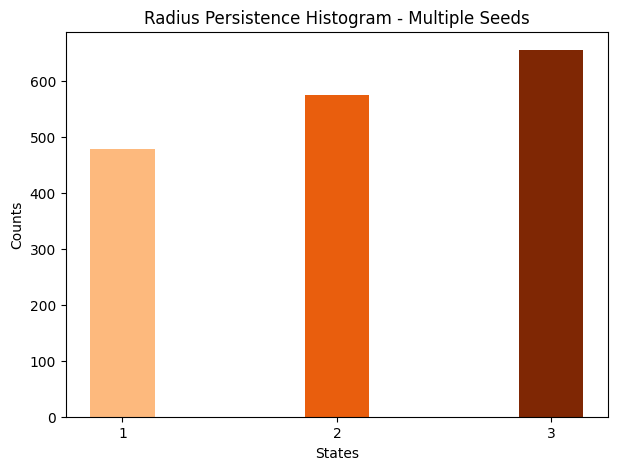

In [23]:

plt.figure(figsize=(7,5))

states,counts = np.unique(medianListR,return_counts=True)

plt.bar(states,counts,width=0.3, color=[cmap(i) for i in range(1,cmap.N)])
plt.xticks(states,np.int64(states))
plt.ylabel("Counts")
plt.xlabel("States")
plt.title("Radius Persistence Histogram - Multiple Seeds")
plt.savefig("../imagens_gerais/multiple_seeds_radius_histogram.jpg")


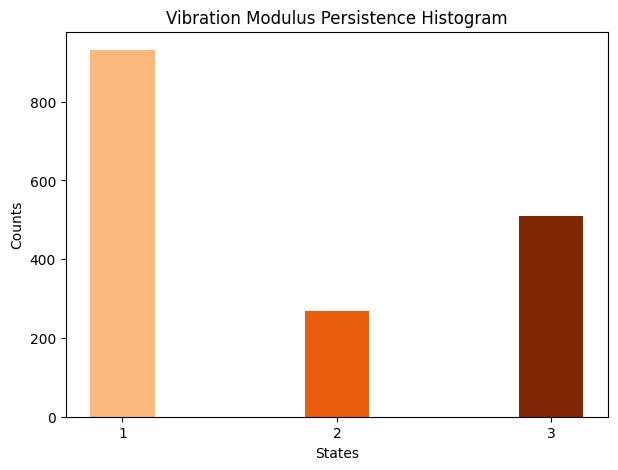

In [24]:
plt.figure(figsize=(7,5))

states,counts = np.unique(medianListV,return_counts=True)

plt.bar(states,counts,width=0.3, color=[cmap(i) for i in range(1,cmap.N)])
plt.xticks(states,np.int64(states))
plt.ylabel("Counts")
plt.xlabel("States")
plt.title("Vibration Modulus Persistence Histogram")
plt.savefig("../imagens_gerais/multiple_seeds_vibration_histogram.jpg")

In [16]:
counts/counts.sum()

array([0.54444444, 0.15730994, 0.29824561])

In [1]:
# plt.figure(figsize=(7,5))
# plt.hist(medianListV)
# plt.title("Histograma da média de Persistência de Estados - Módulo da Vibração")

In [19]:
from scipy.stats import chisquare

# Contagens das classes ao longo das inicializações
observed_counts = np.array([counts[0],counts[1],counts[2]]) # Substituir pelos valores reais
expected_counts = np.array([1/3, 1/3, 1/3]) * sum(observed_counts)

# Teste qui-quadrado de aderência
chi2_stat, p_value = chisquare(f_obs=observed_counts, f_exp=expected_counts)

print(f"Estatística qui-quadrado: {chi2_stat:.4f}, p-valor: {p_value:.4f}")

if p_value < 0.05:
    print("Rejeitamos H0: C ocorre significativamente mais do que o esperado.")
else:
    print("Não há evidências suficientes para afirmar que C ocorre mais que o esperado.")

Estatística qui-quadrado: 27.5474, p-valor: 0.0000
Rejeitamos H0: C ocorre significativamente mais do que o esperado.


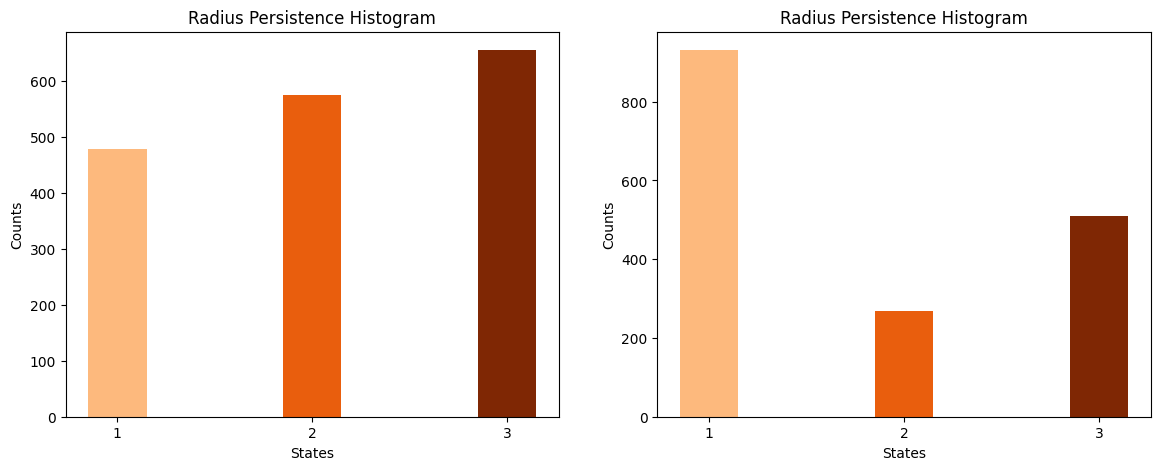

In [ ]:
cmap = plt.get_cmap('Oranges', 4)
fig,axs=plt.subplots(1,2,figsize=(14,5))
states,counts = np.unique(medianListR,return_counts=True)
axs[0].bar(states,counts,width=0.3,color=[cmap(i) for i in range(1,cmap.N)])
axs[0].set_xticks(states,np.int64(states))
axs[0].set_ylabel("Counts")
axs[0].set_xlabel("States")
axs[0].set_title("Radius Persistence Histogram")

states,counts = np.unique(medianListV,return_counts=True)
axs[1].bar(states,counts,width=0.3,color=[cmap(i) for i in range(1,cmap.N)])
axs[1].set_xticks(states,np.int64(states))
axs[1].set_ylabel("Counts")
axs[1].set_xlabel("States")
axs[1].set_title("Radius Persistence Histogram")



plt.savefig("../imagens_gerais/general_seeds_histogram.jpg")